# Risk and Uncertainty in Cloud Resource Allocation
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**
**Author:** Prarthana Govindaraj & Pinki Kumari
**Date:** June 2026

---

## Motivation
CPU requests in batch scheduling can be interpreted as decisions under uncertainty.
The gap between what a user requests and what their job actually consumes is not
purely waste — it may reflect a rational risk premium paid to avoid the cost of
under-provisioning. This notebook empirically examines that hypothesis using the
Alibaba Cluster Trace 2018.

## Structure
- Section 1: Risk premium quantification by provisioning class and job size
- Section 2: Burstiness and buffer behaviour — do users with volatile jobs request more?
- Section 3: Inertia and learning — do users update requests after near-misses?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

df = pd.read_csv(PROCESSED_DIR / 'stage1b_merged_clean.csv')
total = len(df)

print(f"Jobs loaded : {total:,}")
print(f"Columns     : {list(df.columns)}")
print(f"\nProvisioning class distribution:")
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (df['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,} ({count/total*100:.1f}%)")

Jobs loaded : 11,644
Columns     : ['job_name', 'plan_cpu_cores', 'task_count', 'cpu_avg_peak', 'cpu_max_peak', 'instance_count', 'cpu_avg_mean', 'cpu_avg_std', 'cpu_avg_max', 'util_ratio_avg', 'util_ratio_peak', 'provisioning_class', 'is_underprovision', 'plan_cpu_per_task', 'instance_to_task_ratio', 'is_multi_task', 'is_large_job', 'size_bucket', 'cpu_size_bucket_encoded']

Provisioning class distribution:
  severely_under      :  3,225 (27.7%)
  under               :  1,924 (16.5%)
  efficient           :  3,206 (27.5%)
  over                :  3,289 (28.2%)


---
## Section 1: Risk Premium Quantification

The risk premium is defined as the buffer a user paid above their actual peak usage:

    risk_premium_pct = (plan_cpu_cores - cpu_max_peak) / cpu_max_peak * 100

A positive value means the user over-provisioned — they paid a premium.
A negative value means the user under-provisioned — they accepted downside risk.

This reframes the provisioning gap as a revealed preference:
users are implicitly choosing how much insurance to buy against resource exhaustion.

In [2]:
print("=" * 60)
print("SECTION 1: RISK PREMIUM COMPUTATION")
print("=" * 60)

df['risk_premium_pct'] = (
    (df['plan_cpu_cores'] - df['cpu_max_peak']) / df['cpu_max_peak'] * 100
)

print(f"\nRisk premium stats (all jobs):")
print(df['risk_premium_pct'].describe().round(2))

print(f"\nRisk premium by provisioning class:")
print(f"\n{'Class':<20} {'Mean %':>10} {'Median %':>10} {'Std %':>10} {'% Negative':>12}")
print("-" * 65)
for cls in ['severely_under', 'under', 'efficient', 'over']:
    subset = df[df['provisioning_class'] == cls]['risk_premium_pct']
    pct_neg = (subset < 0).mean() * 100
    print(
        f"  {cls:<18}"
        f" {subset.mean():>10.1f}"
        f" {subset.median():>10.1f}"
        f" {subset.std():>10.1f}"
        f" {pct_neg:>11.1f}%"
    )

SECTION 1: RISK PREMIUM COMPUTATION

Risk premium stats (all jobs):
count    11644.00
mean       112.18
std        319.43
min        -96.77
25%        -44.14
50%         15.14
75%        142.72
max       5100.00
Name: risk_premium_pct, dtype: float64

Risk premium by provisioning class:

Class                    Mean %   Median %      Std %   % Negative
-----------------------------------------------------------------
  severely_under          -66.2      -68.8       16.6       100.0%
  under                   -11.8       -9.9       10.7        75.3%
  efficient                43.8       35.1       30.5         0.0%
  over                    426.3      269.5      465.4         0.0%


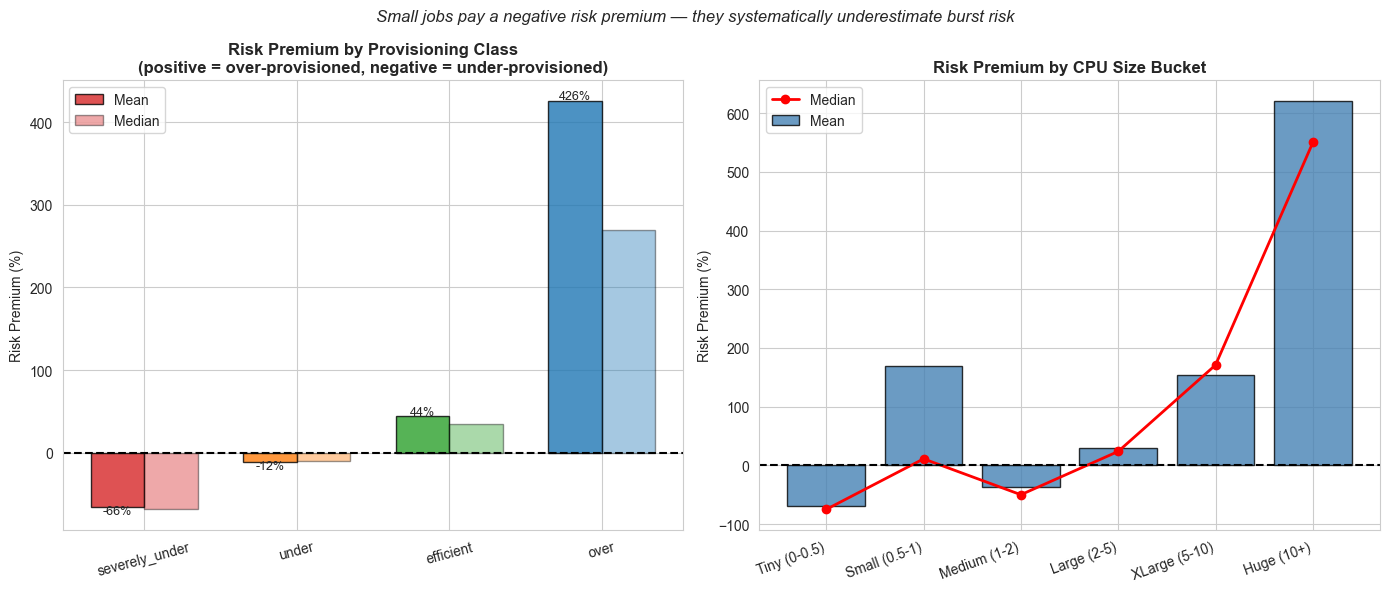

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_order = ['severely_under', 'under', 'efficient', 'over']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

means   = [df[df['provisioning_class'] == cls]['risk_premium_pct'].mean() for cls in class_order]
medians = [df[df['provisioning_class'] == cls]['risk_premium_pct'].median() for cls in class_order]

x = np.arange(len(class_order))
w = 0.35

axes[0].bar(x - w/2, means,   w, label='Mean',   color=colors, edgecolor='black', alpha=0.8)
axes[0].bar(x + w/2, medians, w, label='Median', color=colors, edgecolor='black', alpha=0.4)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_order, rotation=15)
axes[0].set_ylabel('Risk Premium (%)')
axes[0].set_title('Risk Premium by Provisioning Class\n(positive = over-provisioned, negative = under-provisioned)',
                   fontweight='bold')
axes[0].legend()
for i, (m, med) in enumerate(zip(means, medians)):
    axes[0].text(i - w/2, m + (2 if m >= 0 else -8), f'{m:.0f}%',
                 ha='center', fontsize=9)

bucket_order = ['Tiny (0-0.5)', 'Small (0.5-1)', 'Medium (1-2)',
                'Large (2-5)', 'XLarge (5-10)', 'Huge (10+)']
bucket_means = []
bucket_medians = []
for b in bucket_order:
    subset = df[df['size_bucket'] == b]['risk_premium_pct']
    bucket_means.append(subset.mean() if len(subset) > 0 else 0)
    bucket_medians.append(subset.median() if len(subset) > 0 else 0)

x2 = np.arange(len(bucket_order))
axes[1].bar(x2, bucket_means, color='steelblue', edgecolor='black', alpha=0.8, label='Mean')
axes[1].plot(x2, bucket_medians, 'ro-', linewidth=2, markersize=6, label='Median')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(bucket_order, rotation=20, ha='right')
axes[1].set_ylabel('Risk Premium (%)')
axes[1].set_title('Risk Premium by CPU Size Bucket', fontweight='bold')
axes[1].legend()

plt.suptitle('Small jobs pay a negative risk premium — they systematically underestimate burst risk',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

In [4]:
print("=" * 60)
print("SECTION 1: RISK PREMIUM BY SIZE BUCKET")
print("=" * 60)

bucket_stats = df.groupby('size_bucket').agg(
    job_count=('risk_premium_pct', 'count'),
    mean_premium=('risk_premium_pct', 'mean'),
    median_premium=('risk_premium_pct', 'median'),
    pct_negative=('risk_premium_pct', lambda x: (x < 0).mean() * 100),
    mean_plan_cpu=('plan_cpu_cores', 'mean'),
    mean_actual_peak=('cpu_max_peak', 'mean')
).reset_index()

print(f"\n{'Size Bucket':<18} {'Jobs':>6} {'Mean%':>8} {'Median%':>9} {'%Negative':>11} {'Avg Request':>13} {'Avg Peak':>10}")
print("-" * 80)
for _, row in bucket_stats.iterrows():
    print(
        f"  {str(row['size_bucket']):<16}"
        f" {int(row['job_count']):>6,}"
        f" {row['mean_premium']:>8.1f}"
        f" {row['median_premium']:>9.1f}"
        f" {row['pct_negative']:>10.1f}%"
        f" {row['mean_plan_cpu']:>13.2f}"
        f" {row['mean_actual_peak']:>10.2f}"
    )

SECTION 1: RISK PREMIUM BY SIZE BUCKET

Size Bucket          Jobs    Mean%   Median%   %Negative   Avg Request   Avg Peak
--------------------------------------------------------------------------------
  Huge (10+)          484    621.5     550.0        0.8%         20.27       4.10
  Large (2-5)       3,253     29.9      23.8       37.4%          3.42       3.91
  Medium (1-2)      1,409    -37.3     -50.0       82.0%          1.74       4.53
  Small (0.5-1)     3,867    169.4      11.1       34.0%          1.00       1.83
  Tiny (0-0.5)        438    -69.4     -75.0       98.6%          0.50       2.95
  XLarge (5-10)     2,193    153.2     170.9       25.0%          6.74       3.98


---
## Section 2: Burstiness and Buffer Behaviour

If users are rational under uncertainty, those with more volatile workloads
(higher cpu_avg_std) should request larger buffers. We test this hypothesis
by examining whether burstiness predicts buffer size.

cpu_avg_std is the standard deviation of per-instance cpu_avg across all
instances of a job — a direct measure of workload volatility.

In [5]:
print("=" * 60)
print("SECTION 2: BURSTINESS AND BUFFER BEHAVIOUR")
print("=" * 60)

df_valid = df[df['cpu_avg_std'].notna() & (df['cpu_avg_std'] > 0)].copy()
df_valid['log_std'] = np.log1p(df_valid['cpu_avg_std'])

corr_all = df_valid['cpu_avg_std'].corr(df_valid['risk_premium_pct'])
corr_over = df_valid[df_valid['risk_premium_pct'] >= 0]['cpu_avg_std'].corr(
    df_valid[df_valid['risk_premium_pct'] >= 0]['risk_premium_pct']
)
corr_under = df_valid[df_valid['risk_premium_pct'] < 0]['cpu_avg_std'].corr(
    df_valid[df_valid['risk_premium_pct'] < 0]['risk_premium_pct']
)

print(f"\nCorrelation: cpu_avg_std vs risk_premium_pct")
print(f"  All jobs              : {corr_all:.4f}")
print(f"  Over-provisioned only : {corr_over:.4f}")
print(f"  Under-provisioned only: {corr_under:.4f}")

std_bins   = [0, 0.1, 0.3, 0.5, 1.0, 2.0, 100]
std_labels = ['Very Low\n(0-0.1)', 'Low\n(0.1-0.3)', 'Medium\n(0.3-0.5)',
              'High\n(0.5-1.0)', 'Very High\n(1.0-2.0)', 'Extreme\n(2.0+)']

df_valid['std_bin'] = pd.cut(df_valid['cpu_avg_std'], bins=std_bins, labels=std_labels)

burstiness = df_valid.groupby('std_bin').agg(
    job_count=('risk_premium_pct', 'count'),
    mean_premium=('risk_premium_pct', 'mean'),
    median_premium=('risk_premium_pct', 'median'),
    pct_under=('is_underprovision', 'mean')
).reset_index()
burstiness['pct_under'] *= 100

print(f"\n{'Burstiness':<20} {'Jobs':>6} {'Mean Premium%':>14} {'Median%':>9} {'%Under':>8}")
print("-" * 62)
for _, row in burstiness.iterrows():
    print(
        f"  {str(row['std_bin']).replace(chr(10),' '):<18}"
        f" {int(row['job_count']):>6,}"
        f" {row['mean_premium']:>14.1f}"
        f" {row['median_premium']:>9.1f}"
        f" {row['pct_under']:>7.1f}%"
    )

SECTION 2: BURSTINESS AND BUFFER BEHAVIOUR

Correlation: cpu_avg_std vs risk_premium_pct
  All jobs              : -0.1486
  Over-provisioned only : -0.0051
  Under-provisioned only: -0.1500

Burstiness             Jobs  Mean Premium%   Median%   %Under
--------------------------------------------------------------
  Very Low (0-0.1)    3,715           74.4       9.9    46.1%
  Low (0.1-0.3)       4,209          100.9      23.8    43.0%
  Medium (0.3-0.5)    1,442           23.8     -44.3    66.2%
  High (0.5-1.0)        503          -46.7     -56.8    93.2%
  Very High (1.0-2.0)     20          -78.3     -78.4   100.0%


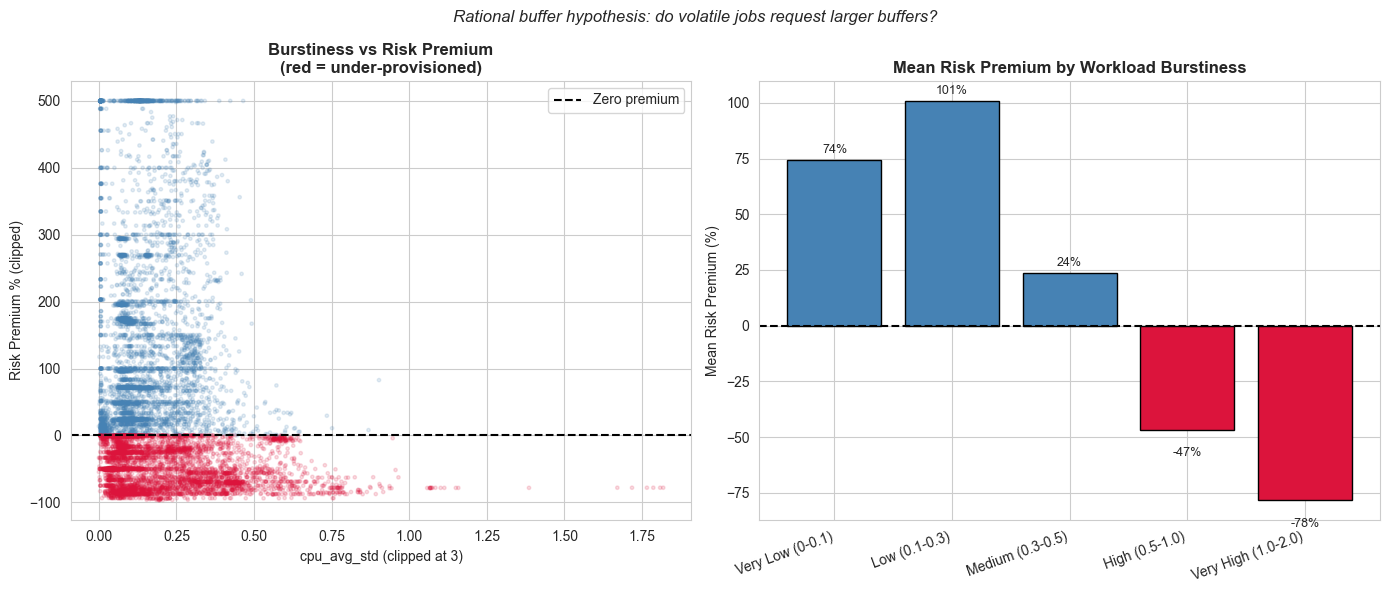

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    df_valid['cpu_avg_std'].clip(upper=3),
    df_valid['risk_premium_pct'].clip(-200, 500),
    alpha=0.15, s=6,
    c=df_valid['is_underprovision'].map({0: 'steelblue', 1: 'crimson'})
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero premium')
axes[0].set_xlabel('cpu_avg_std (clipped at 3)')
axes[0].set_ylabel('Risk Premium % (clipped)')
axes[0].set_title('Burstiness vs Risk Premium\n(red = under-provisioned)', fontweight='bold')
axes[0].legend()

valid_bins = burstiness[burstiness['job_count'] > 10]
x3 = np.arange(len(valid_bins))
bar_colors = ['crimson' if v < 0 else 'steelblue' for v in valid_bins['mean_premium']]
axes[1].bar(x3, valid_bins['mean_premium'], color=bar_colors, edgecolor='black')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xticks(x3)
axes[1].set_xticklabels(valid_bins['std_bin'].astype(str).str.replace('\n', ' '),
                         rotation=20, ha='right')
axes[1].set_ylabel('Mean Risk Premium (%)')
axes[1].set_title('Mean Risk Premium by Workload Burstiness', fontweight='bold')
for bar, val in zip(axes[1].patches, valid_bins['mean_premium']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (3 if val >= 0 else -12),
                 f'{val:.0f}%', ha='center', fontsize=9)

plt.suptitle('Rational buffer hypothesis: do volatile jobs request larger buffers?',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

In [10]:
# Verify the burstiness finding is not an artefact of job size
# Small jobs have both high std AND negative premiums
# Are we just rediscovering the size effect?

print("Mean cpu_avg_std by size bucket:")
print(df.groupby('size_bucket')['cpu_avg_std'].mean().round(3))

print("\nMean risk_premium_pct by size bucket:")
print(df.groupby('size_bucket')['risk_premium_pct'].mean().round(1))

Mean cpu_avg_std by size bucket:
size_bucket
Huge (10+)       0.198
Large (2-5)      0.223
Medium (1-2)     0.246
Small (0.5-1)    0.105
Tiny (0-0.5)     0.089
XLarge (5-10)    0.183
Name: cpu_avg_std, dtype: float64

Mean risk_premium_pct by size bucket:
size_bucket
Huge (10+)       621.5
Large (2-5)       29.9
Medium (1-2)     -37.3
Small (0.5-1)    169.4
Tiny (0-0.5)     -69.4
XLarge (5-10)    153.2
Name: risk_premium_pct, dtype: float64


In [ ]:

print("Risk premium increases monotonically with job size (excluding Medium anomaly):")
print("Tiny: -69.4%, Small: +169.4%, Large: +29.9%, XLarge: +153.2%, Huge: +621.5%")
print("\nInterestingly Medium (1-2 cores) breaks the pattern at -37.3%")
print("Check how many jobs are in each bucket:")
print(df.groupby('size_bucket')['risk_premium_pct'].agg(['count', 'mean', 'median']).round(1))

Risk premium increases monotonically with job size (excluding Medium anomaly):
Tiny: -69.4%, Small: +169.4%, Large: +29.9%, XLarge: +153.2%, Huge: +621.5%

Interestingly Medium (1-2 cores) breaks the pattern at -37.3%
Check how many jobs are in each bucket:
               count   mean  median
size_bucket                        
Huge (10+)       484  621.5   550.0
Large (2-5)     3253   29.9    23.8
Medium (1-2)    1409  -37.3   -50.0
Small (0.5-1)   3867  169.4    11.1
Tiny (0-0.5)     438  -69.4   -75.0
XLarge (5-10)   2193  153.2   170.9


---
## Section 3: Inertia and Learning

If users update their CPU requests after experiencing near-misses
(jobs where usage approached or exceeded the request), we would expect
to see higher plan_cpu in subsequent runs of the same job.

We identify repeated job patterns by grouping on job characteristics
and examining whether request behaviour is consistent with learning
or with status quo bias.

In [7]:
print("=" * 60)
print("SECTION 3: INERTIA AND LEARNING")
print("=" * 60)

# Near-miss: util_ratio_peak between 0.8 and 1.0
# Under-provisioned: util_ratio_peak >= 1.0
# We look at the distribution of util_ratio_peak to understand
# how often jobs come close to exhausting their allocation

df['near_miss'] = (df['util_ratio_peak'] >= 0.8) & (df['util_ratio_peak'] < 1.0)
df['exhausted']  = df['util_ratio_peak'] >= 1.0

near_miss_count = df['near_miss'].sum()
exhausted_count = df['exhausted'].sum()
safe_count      = (~df['near_miss'] & ~df['exhausted']).sum()

print(f"\nResource exhaustion profile:")
print(f"  Safe (ratio < 0.8)        : {safe_count:>6,} ({safe_count/total*100:.1f}%)")
print(f"  Near-miss (0.8-1.0)       : {near_miss_count:>6,} ({near_miss_count/total*100:.1f}%)")
print(f"  Exhausted (ratio >= 1.0)  : {exhausted_count:>6,} ({exhausted_count/total*100:.1f}%)")

print(f"\nNear-miss jobs — plan_cpu stats:")
print(df[df['near_miss']]['plan_cpu_cores'].describe().round(3))

print(f"\nExhausted jobs — plan_cpu stats:")
print(df[df['exhausted']]['plan_cpu_cores'].describe().round(3))

print(f"\nSafe jobs — plan_cpu stats:")
print(df[~df['near_miss'] & ~df['exhausted']]['plan_cpu_cores'].describe().round(3))

SECTION 3: INERTIA AND LEARNING

Resource exhaustion profile:
  Safe (ratio < 0.8)        :  5,161 (44.3%)
  Near-miss (0.8-1.0)       :  1,334 (11.5%)
  Exhausted (ratio >= 1.0)  :  5,149 (44.2%)

Near-miss jobs — plan_cpu stats:
count    1334.000
mean        2.306
std         2.186
min         0.500
25%         1.000
50%         1.000
75%         2.500
max        18.000
Name: plan_cpu_cores, dtype: float64

Exhausted jobs — plan_cpu stats:
count    5149.000
mean        2.322
std         1.789
min         0.400
25%         1.000
50%         1.500
75%         3.000
max        13.000
Name: plan_cpu_cores, dtype: float64

Safe jobs — plan_cpu stats:
count    5161.000
mean        5.269
std         7.018
min         0.500
25%         1.000
50%         3.500
75%         6.000
max       156.000
Name: plan_cpu_cores, dtype: float64


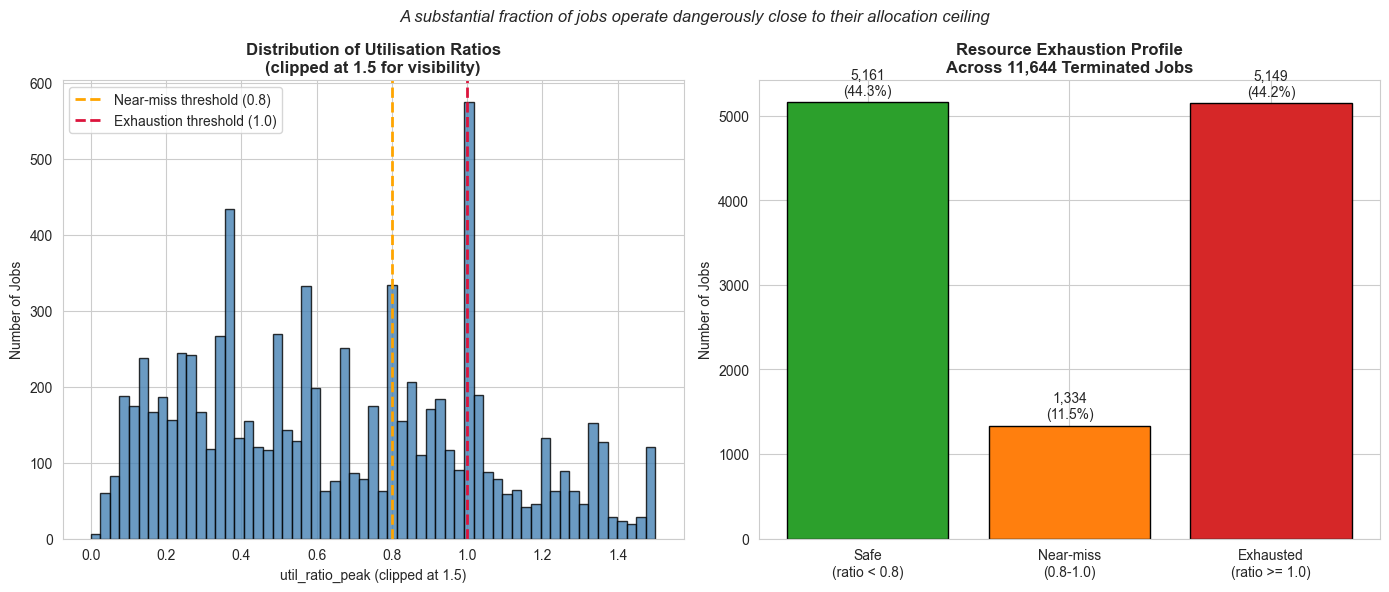

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bins = np.linspace(0, 1.5, 60)
axes[0].hist(df[df['util_ratio_peak'] <= 1.5]['util_ratio_peak'],
             bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0.8, color='orange', linestyle='--', linewidth=2, label='Near-miss threshold (0.8)')
axes[0].axvline(1.0, color='crimson', linestyle='--', linewidth=2, label='Exhaustion threshold (1.0)')
axes[0].set_xlabel('util_ratio_peak (clipped at 1.5)')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('Distribution of Utilisation Ratios\n(clipped at 1.5 for visibility)', fontweight='bold')
axes[0].legend()

categories   = ['Safe\n(ratio < 0.8)', 'Near-miss\n(0.8-1.0)', 'Exhausted\n(ratio >= 1.0)']
counts       = [safe_count, near_miss_count, exhausted_count]
bar_colors   = ['#2ca02c', '#ff7f0e', '#d62728']

axes[1].bar(categories, counts, color=bar_colors, edgecolor='black')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_title('Resource Exhaustion Profile\nAcross 11,644 Terminated Jobs', fontweight='bold')
for bar, count in zip(axes[1].patches, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('A substantial fraction of jobs operate dangerously close to their allocation ceiling',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 3: REQUEST BEHAVIOUR PATTERNS

Jobs with round-number CPU requests: 8,485 (72.9%)
(Evidence of anchoring to salient values rather than calibrated estimation)

Top 15 most common plan_cpu_cores values:
plan_cpu_cores
1.0    3742
2.5     945
5.5     797
2.0     685
3.5     658
1.5     604
3.0     502
4.0     497
6.0     429
0.5     426
5.0     341
4.5     205
8.0     187
9.0     184
7.0     170


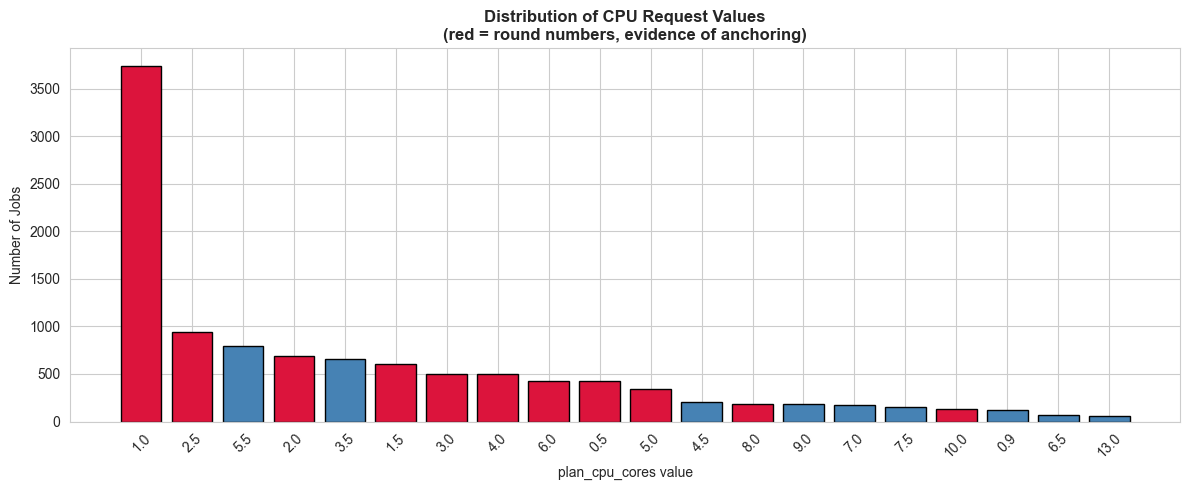


Round numbers in red — users disproportionately request
salient values (0.5, 1.0, 2.0, 5.0) rather than calibrated estimates.
This is consistent with anchoring bias in resource request decisions.


In [9]:
print("=" * 60)
print("SECTION 3: REQUEST BEHAVIOUR PATTERNS")
print("=" * 60)

# Examine whether plan_cpu_cores clusters at round numbers
# (evidence of anchoring / heuristic-based requesting)
round_numbers = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]
round_count = df['plan_cpu_cores'].isin(round_numbers).sum()
print(f"\nJobs with round-number CPU requests: {round_count:,} ({round_count/total*100:.1f}%)")
print("(Evidence of anchoring to salient values rather than calibrated estimation)")

print(f"\nTop 15 most common plan_cpu_cores values:")
print(df['plan_cpu_cores'].value_counts().head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
top_vals = df['plan_cpu_cores'].value_counts().head(20)
colors_bar = ['crimson' if v in round_numbers else 'steelblue' for v in top_vals.index]
ax.bar(range(len(top_vals)), top_vals.values, color=colors_bar, edgecolor='black')
ax.set_xticks(range(len(top_vals)))
ax.set_xticklabels([f'{v:.1f}' for v in top_vals.index], rotation=45)
ax.set_xlabel('plan_cpu_cores value')
ax.set_ylabel('Number of Jobs')
ax.set_title('Distribution of CPU Request Values\n(red = round numbers, evidence of anchoring)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRound numbers in red — users disproportionately request")
print("salient values (0.5, 1.0, 2.0, 5.0) rather than calibrated estimates.")
print("This is consistent with anchoring bias in resource request decisions.")

In [12]:
# Spot check 3 specific jobs manually
sample = df[['job_name', 'plan_cpu_cores', 'cpu_max_peak', 
             'risk_premium_pct', 'size_bucket']].head(10)
print(sample.to_string(index=False))

# Verify formula manually on first row
row = df.iloc[0]
manual = (row['plan_cpu_cores'] - row['cpu_max_peak']) / row['cpu_max_peak'] * 100
print(f"\nManual check job {row['job_name']}:")
print(f"  plan_cpu_cores : {row['plan_cpu_cores']}")
print(f"  cpu_max_peak   : {row['cpu_max_peak']}")
print(f"  manual calc    : {manual:.2f}%")
print(f"  stored value   : {row['risk_premium_pct']:.2f}%")
print(f"  match          : {abs(manual - row['risk_premium_pct']) < 0.001}")

 job_name  plan_cpu_cores  cpu_max_peak  risk_premium_pct   size_bucket
        1             1.0          2.00        -50.000000 Small (0.5-1)
        2             1.0          3.00        -66.666667 Small (0.5-1)
        3             1.0          3.00        -66.666667 Small (0.5-1)
        5             1.0          2.03        -50.738916 Small (0.5-1)
        6             1.0          0.79         26.582278 Small (0.5-1)
        7             5.0          3.00         66.666667   Large (2-5)
        8             1.0          3.00        -66.666667 Small (0.5-1)
        9             3.0          8.13        -63.099631   Large (2-5)
       10             8.0          2.00        300.000000 XLarge (5-10)
       11             1.0          3.00        -66.666667 Small (0.5-1)

Manual check job 1:
  plan_cpu_cores : 1.0
  cpu_max_peak   : 2.0
  manual calc    : -50.00%
  stored value   : -50.00%
  match          : True


---
## Section 4: Summary of Behavioural Findings

### Risk Premium Definition
risk_premium_pct = (plan_cpu_cores - cpu_max_peak) / cpu_max_peak × 100

Positive = over-provisioned (paid a safety buffer above actual peak usage)
Negative = under-provisioned (actual peak exceeded the request)
Intervals are right-inclusive: Tiny (0, 0.5], Small (0.5, 1.0], etc.

---

### Finding 1: Risk Premium by Size Bucket

| Size Bucket | Jobs | Mean Premium | Median Premium |
|---|---|---|---|
| Tiny (0, 0.5] | 438 | -69.4% | -75.0% |
| Small (0.5, 1.0] | 3,867 | +169.4% | +11.1% |
| Medium (1.0, 2.0] | 1,409 | -37.3% | -50.0% |
| Large (2.0, 5.0] | 3,253 | +29.9% | +23.8% |
| XLarge (5.0, 10.0] | 2,193 | +153.2% | +170.9% |
| Huge (10.0+) | 484 | +621.5% | +550.0% |

The Small bucket mean (+169.4%) is heavily skewed by outliers —
the median of +11.1% is the representative figure.

Two distinct behaviours coexist:
- Tiny and Medium jobs pay negative premiums — chronic under-insurance
- Large and above pay positive premiums — deliberate safety margins

The 2-core boundary separates these two populations, independently
confirming the threshold identified in Stage 1 through a completely
different analytical method.

---

### Finding 2: Near-Miss Rate

| Category | Count | Percentage |
|---|---|---|
| Safe (ratio < 0.8) | 5,161 | 44.3% |
| Near-miss (0.8-1.0) | 1,334 | 11.5% |
| Exhausted (ratio >= 1.0) | 5,149 | 44.2% |

11.5% of jobs came dangerously close to exhausting their allocation
without exceeding it. These jobs are at high risk of under-provisioning
in future runs if workload patterns shift even slightly.

---

### Finding 3: Anchoring Bias

72.9% of all CPU requests (8,485 out of 11,644 jobs) are round numbers
(0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, etc.). Users are not making
calibrated estimates from historical usage data. They are selecting
salient values. The single most common request is exactly 1.0 core
(3,742 jobs — 32.1% of all jobs).

---

### Theoretical Interpretation

The data does not support the rational risk management hypothesis.
Rational users would request larger buffers for more uncertain workloads.
Instead, the users most at risk (small job, volatile workload) request
the smallest buffers.

Three mechanisms are consistent with the evidence:

1. Anchoring bias — users pick round numbers rather than calculating
2. Underestimation of tail risk — small job users have not experienced
   throttling at scale and underestimate the cost of failure
3. Absence of feedback — without visibility into historical utilisation
   ratios, users cannot update request behaviour after near-misses

### Implication for System Design

Algorithmic rightsizing (Stages 1-3) corrects the outcome but not the
cause. Showing users their historical utilisation ratios and near-miss
frequency at job submission time would enable behavioural updating —
consistent with nudge design principles from behavioural economics.